In [327]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [328]:
pd.set_option('display.max_columns', None)

In [329]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [330]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 11,4.00,19753.00,2025.00,Built Up area: 225 (188.13 sq.m.)Carpet area: ...,5,4,1,2.00,North-East,Undefined,NaN,225.00,180.00,0,0,0,0,0,1,0
1,flat,indiabulls enigma,sector 110,3.30,9850.00,3350.00,Super Built up area 3350(311.23 sq.m.),4,5,3,7.00,East,Relatively New,3350.00,NaN,NaN,0,1,0,0,0,1,101
2,flat,puri emerald bay,sector 104,2.30,9387.00,2450.00,Super Built up area 2450(227.61 sq.m.),3,4,3+,10.00,North-East,Moderately Old,2450.00,NaN,NaN,0,1,0,0,0,1,101
3,house,nirvana cedar crest,sector 50,3.99,8866.00,4500.00,Plot area 4500(418.06 sq.m.),4,5,3+,4.00,North-East,New Property,NaN,4500.00,NaN,0,1,0,1,0,0,112
4,flat,bptp terra,sector 37,1.45,8006.00,1811.00,Super Built up area 1811(168.25 sq.m.)Built Up...,3,3,3,8.00,South-East,Relatively New,1811.00,1711.00,1611.00,0,0,0,0,0,1,149


In [331]:
df.shape

(3753, 23)

### Price

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

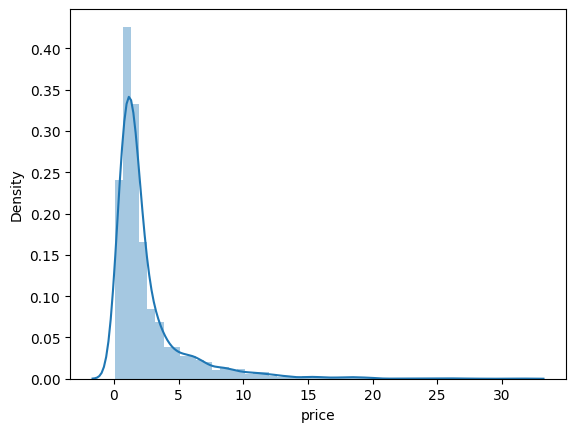

In [332]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

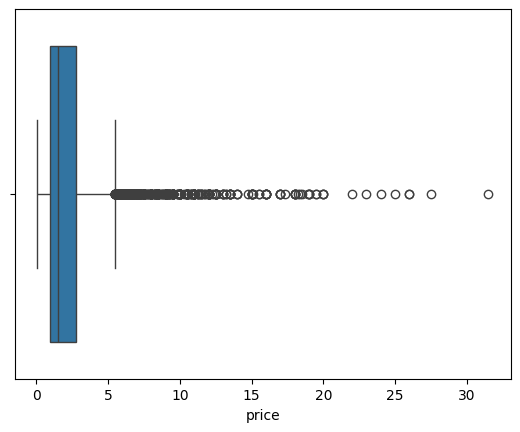

In [333]:
sns.boxplot(x=df['price'])

In [334]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(435,
 count   435.00
 mean      9.20
 std       4.05
 min       5.49
 25%       6.42
 50%       8.00
 75%      10.55
 max      31.50
 Name: price, dtype: float64)

In [335]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1575,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.00,9000.00,Plot area 1000(836.13 sq.m.),7,9,3+,3.00,North-East,Moderately Old,NaN,9000.00,NaN,1,1,1,1,0,2,74
2310,house,independent,sector 43,27.50,24366.00,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.00,North-East,Relatively New,NaN,11286.00,NaN,1,1,0,1,1,0,42
3131,house,independent,sector 26,26.00,82540.00,3150.00,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.00,North-West,New Property,NaN,400.00,350.00,1,1,1,1,0,0,72
2400,house,dlf city plots,sector 26,26.00,57206.00,4545.00,Plot area 505(422.24 sq.m.),6,7,3+,2.00,North-East,New Property,NaN,4545.00,NaN,1,1,0,1,1,0,138
2101,house,suncity township,sector 54,25.00,31111.00,8036.00,Plot area 1000(836.13 sq.m.),4,4,3+,2.00,North,Moderately Old,NaN,1000.00,NaN,1,1,1,1,0,1,0
1278,house,emaar the palm springs,sector 54,24.00,600000.00,400.00,Plot area 400(37.16 sq.m.),5,5,2,1.00,North-East,Old Property,NaN,400.00,NaN,1,1,0,1,0,0,122
1507,house,independent,sector 26,23.00,25556.00,9000.00,Plot area 1000(836.13 sq.m.),4,4,3+,2.00,South-West,Relatively New,NaN,9000.00,NaN,1,1,1,1,0,0,145
2846,house,vipul tatvam villa,sector 48,22.00,26667.00,8250.00,Plot area 1000(836.13 sq.m.),5,6,3,3.00,NaN,Moderately Old,NaN,1000.00,NaN,0,1,0,0,0,1,54
717,house,independent,sector 26,20.00,44444.00,4500.00,Plot area 500(418.06 sq.m.),5,7,3+,3.00,West,Relatively New,NaN,4500.00,NaN,0,1,0,1,0,2,97
3314,house,luxury dlf city floors,sector 26,20.00,48889.00,4091.00,Plot area 500(418.06 sq.m.),16,16,3+,4.00,NaN,New Property,NaN,500.00,NaN,0,1,0,0,0,0,31


In [336]:
#outliers.to_excel('outlier_price.xlsx',index=False)

#### on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### price_per_sqft

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

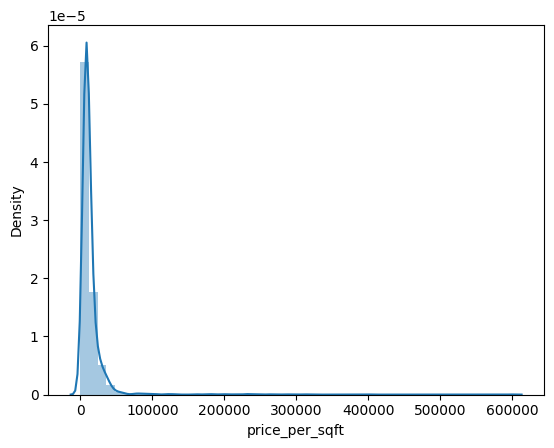

In [337]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

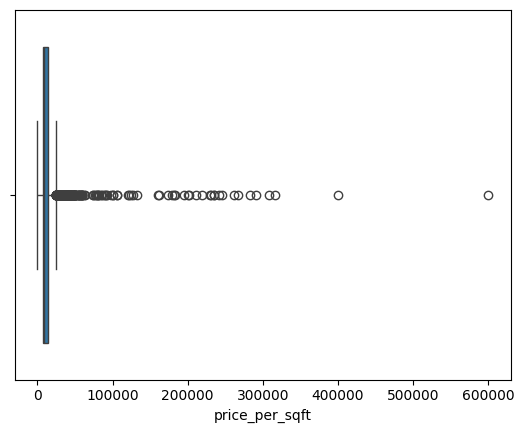

In [338]:
sns.boxplot(x=df['price_per_sqft'])

In [339]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(359,
 count      359.00
 mean     53226.91
 std      61158.46
 min      24510.00
 25%      28274.50
 50%      33665.00
 75%      42208.00
 max     600000.00
 Name: price_per_sqft, dtype: float64)

In [340]:
#outliers.to_excel('outlier_sqft.xlsx',index=False)

In [341]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [342]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [343]:
outliers_sqft['price_per_sqft'].describe()

count     359.00
mean    29145.84
std     12528.04
min      2723.00
25%     25549.50
50%     29861.00
75%     35543.00
max     82540.00
Name: price_per_sqft, dtype: float64

In [344]:
df.update(outliers_sqft)

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

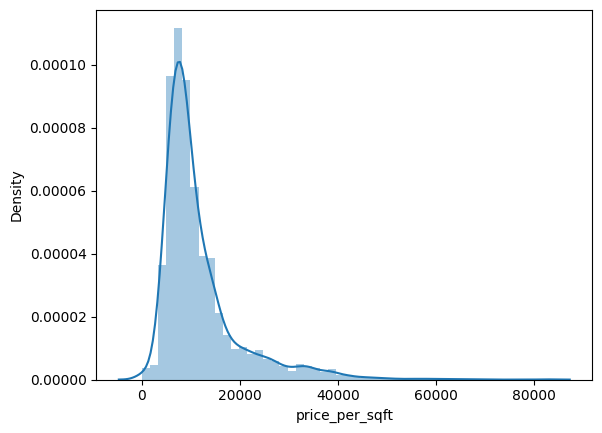

In [345]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

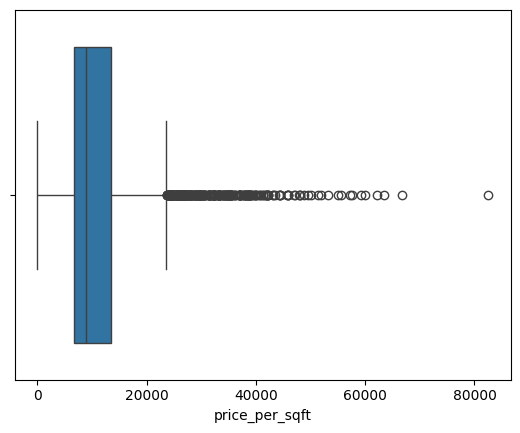

In [346]:
sns.boxplot(x=df['price_per_sqft'])

In [347]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
715,house,cloudnine cottages,sector 48,5.50,55000.00,1000.00,Plot area 1000(92.9 sq.m.),3,3,0,1.00,NaN,Moderately Old,NaN,1000.00,NaN,0,0,0,0,0,1,0
957,house,independent,sector 25,16.00,59259.00,2700.00,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.00,West,New Property,NaN,325.00,300.00,1,1,1,1,0,0,72
1132,house,emaar mgf marbella,sector 66,18.00,55556.00,3240.00,Plot area 360(301.01 sq.m.),4,4,3+,3.00,East,Moderately Old,NaN,3240.00,NaN,1,1,0,1,0,2,75
1277,house,unitech escape,sector 50,10.80,60000.00,1800.00,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.00,North,Relatively New,NaN,250.00,200.00,1,1,1,1,0,0,103
1278,house,emaar the palm springs,sector 54,24.00,66667.00,3600.00,Plot area 400(37.16 sq.m.),5,5,2,1.00,North-East,Old Property,NaN,400.00,NaN,1,1,0,1,0,0,122
1595,house,malibu towne,sector 47,8.50,53125.00,1600.00,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.00,North,New Property,NaN,1600.00,NaN,0,0,0,0,0,0,99
1815,house,independent,sector 26,14.75,51864.00,2844.00,Plot area 316(264.22 sq.m.),16,20,3+,4.00,East,New Property,NaN,2844.00,NaN,1,1,1,1,0,0,153
2371,house,project housing board colony,sector 31,8.00,63492.00,1260.00,Built Up area: 140 (117.06 sq.m.),2,1,0,1.00,NaN,Undefined,NaN,140.00,NaN,0,0,0,0,0,1,0
2400,house,dlf city plots,sector 26,26.00,57206.00,4545.00,Plot area 505(422.24 sq.m.),6,7,3+,2.00,North-East,New Property,NaN,4545.00,NaN,1,1,0,1,1,0,138
3131,house,independent,sector 26,26.00,82540.00,3150.00,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.00,North-West,New Property,NaN,400.00,350.00,1,1,1,1,0,0,72


In [348]:
df[df['price_per_sqft']>50000].shape

(13, 23)

In [349]:
#remove outliers
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

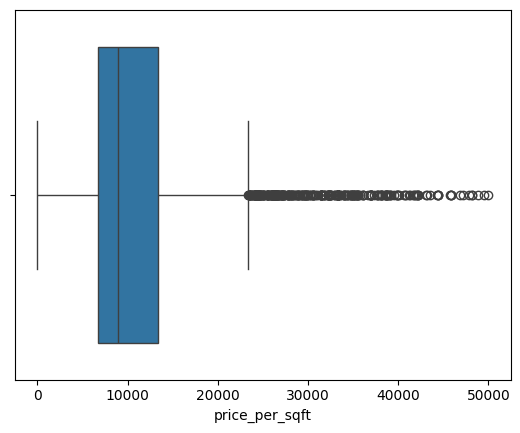

In [350]:
sns.boxplot(x=df['price_per_sqft'])

### Area

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

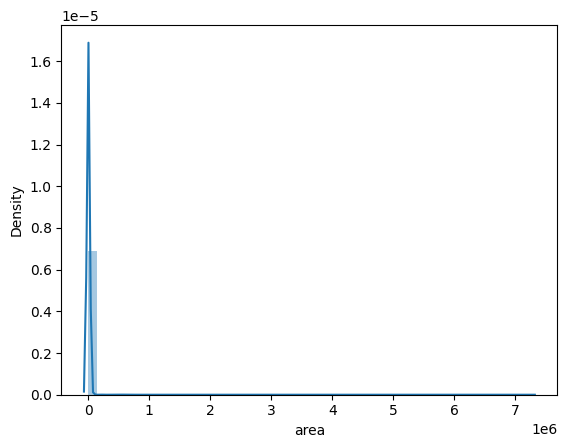

In [351]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

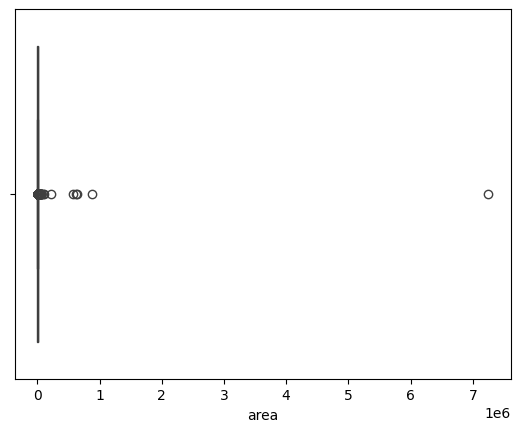

In [352]:
sns.boxplot(x=df['area'])

In [353]:
df['area'].describe()

count      3722.00
mean       4893.47
std      120992.61
min         145.00
25%        1258.25
50%        1750.00
75%        2350.00
max     7250000.00
Name: area, dtype: float64

In [354]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2152,flat,hcbs sports ville,sohna,0.35,4.00,875000.00,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.00,NaN,Relatively New,NaN,737147.00,NaN,0,0,0,0,0,2,44
2305,flat,ramsons kshitij,sector 95,0.31,5.00,620000.00,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.00,North-East,Relatively New,NaN,NaN,607936.00,1,0,0,0,1,1,65
2407,house,independent,sector 50,5.00,232.00,215517.00,Plot area 2(1011.71 sq.m.),6,5,3+,2.00,NaN,New Property,NaN,2.00,NaN,1,1,0,1,1,0,0
2606,flat,signature the roselia,sector 95,0.45,7.00,642857.00,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.00,South-West,New Property,NaN,NaN,569243.00,0,0,0,0,0,1,76
3108,flat,signature global solera 2,sector 107,0.51,9.00,566667.00,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.00,North,New Property,NaN,NaN,514396.00,0,0,0,0,0,1,44
3622,house,independent,sector 10,1.45,2.00,7250000.00,Plot area 200(809372 sq.m.),4,3,3+,3.00,South,Moderately Old,NaN,200.00,NaN,0,0,0,0,0,1,0


In [355]:
df = df[df['area'] < 100000]

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

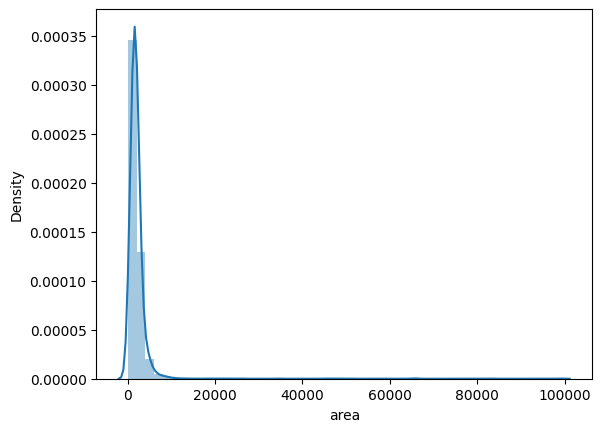

In [356]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

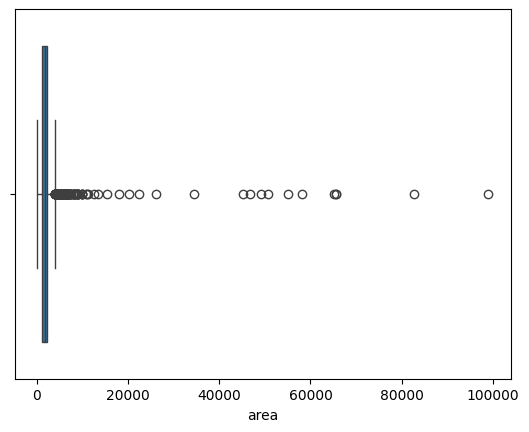

In [357]:
sns.boxplot(x=df['area'])

In [358]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 21, 1066, 2743, 3562, 2094, 3181, 3649, 816, 124

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
21,house,independent,sector 26,18.40,1859.00,98978.00,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.00,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,0,60
1726,house,ganpati heights apartment,sector 12,1.25,151.00,82781.00,Plot area 115(7692.86 sq.m.),10,6,2,3.00,South-East,Old Property,NaN,115.00,NaN,0,0,0,0,1,1,7
1066,flat,rof ananda,sector 95,0.38,58.00,65517.00,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.00,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,1,15
2743,flat,rof ananda,sector 95,0.38,58.00,65517.00,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.00,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,1,51
3634,house,dlf city plot phase 4,sector 28,13.00,1992.00,65261.00,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.00,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
3562,flat,pyramid elite,sector 86,0.46,79.00,58228.00,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.00,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,1,15
2094,flat,rof ananda,sector 95,0.33,60.00,55000.00,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.00,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,1,37
3199,house,independent,sector 51,5.50,1087.00,50598.00,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.00,North-East,Relatively New,NaN,8260.00,4860.00,0,0,0,1,0,0,49
3181,flat,signature the serenas,sohna,0.28,57.00,49123.00,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.00,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,1,37
3022,house,independent,sector 25,7.30,1560.00,46795.00,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.00,North-West,Relatively New,NaN,5800.00,5200.00,0,1,1,0,0,0,109


In [359]:
df.drop(index=[21, 1066, 2743, 3562, 2094, 3181, 3649, 816, 124], inplace=True)

In [360]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1726,house,ganpati heights apartment,sector 12,1.25,151.00,82781.00,Plot area 115(7692.86 sq.m.),10,6,2,3.00,South-East,Old Property,NaN,115.00,NaN,0,0,0,0,1,1,7
3634,house,dlf city plot phase 4,sector 28,13.00,1992.00,65261.00,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.00,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
3199,house,independent,sector 51,5.50,1087.00,50598.00,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.00,North-East,Relatively New,NaN,8260.00,4860.00,0,0,0,1,0,0,49
3022,house,independent,sector 25,7.30,1560.00,46795.00,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.00,North-West,Relatively New,NaN,5800.00,5200.00,0,1,1,0,0,0,109
1947,flat,ramsons kshitij,sector 95,0.24,53.00,45283.00,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.00,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,1,33
2039,house,independent,sector 5,1.45,557.00,26032.00,Plot area 26000(2415.48 sq.m.),4,4,2,2.00,East,Moderately Old,NaN,26000.00,NaN,0,1,0,1,0,1,62
3258,house,independent,sector 57,6.25,2778.00,22498.00,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.00,North-East,New Property,NaN,2660.00,2500.00,0,1,0,0,0,0,61
3647,house,independent,sector 43,5.50,2716.00,20250.00,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.00,East,Moderately Old,NaN,2850.00,2250.00,1,1,0,1,1,0,123
3241,flat,godrej air,sector 85,2.50,1379.00,18129.00,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.00,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,0,44
2872,house,unitech aspen greens,sector 50,6.95,4490.00,15479.00,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.00,North-East,Moderately Old,NaN,2160.00,1720.00,0,1,0,0,0,1,160


In [361]:
df.loc[1726,'area'] = 115*9
df.loc[3634,'area'] = 7250
df.loc[1947,'area'] = 4270
df.loc[3199,'area'] = 8260
df.loc[2039,'area'] = 2415
df.loc[3022,'area'] = 5800
df.loc[3258,'area'] = 2660
df.loc[3647,'area'] = 2850
df.loc[3241,'area'] = 1812
df.loc[2872,'area'] = 2160
df.loc[3014,'area'] = 1175

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

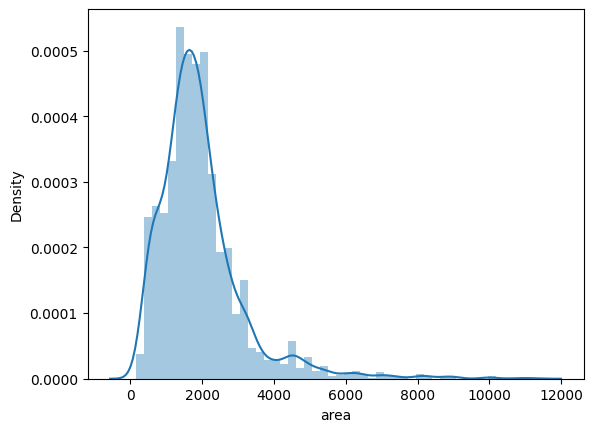

In [362]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

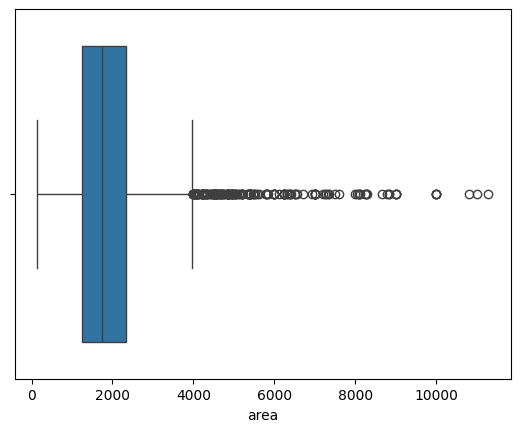

In [363]:
sns.boxplot(x=df['area'])

In [364]:
df['area'].describe()

count    3707.00
mean     1951.68
std      1223.89
min       145.00
25%      1250.50
50%      1745.00
75%      2339.00
max     11286.00
Name: area, dtype: float64

### Bedroom

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

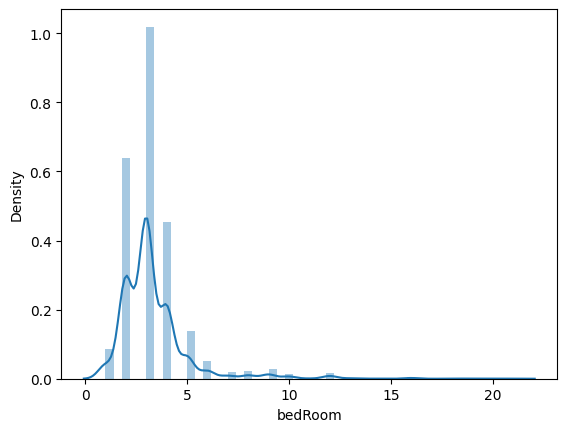

In [365]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

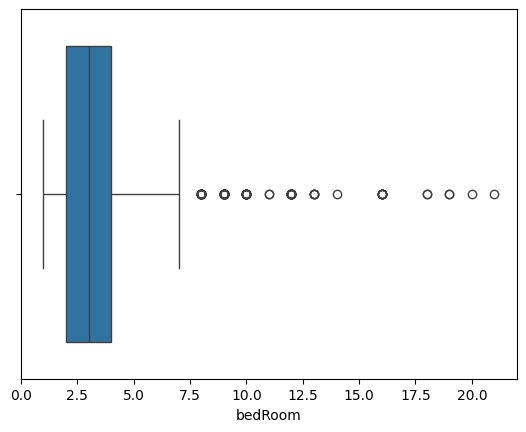

In [366]:
sns.boxplot(x=df['bedRoom'])

In [367]:
df['bedRoom'].describe()

count   3707.00
mean       3.34
std        1.83
min        1.00
25%        2.00
50%        3.00
75%        4.00
max       21.00
Name: bedRoom, dtype: float64

In [368]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
509,house,independent,sector 54,5.00,43066.00,1161.00,Plot area 129(107.86 sq.m.),21,21,3+,5.00,North,Relatively New,NaN,1161.00,NaN,0,1,0,0,0,2,49
2052,house,independent,sector 43,4.50,39062.00,1152.00,Plot area 128(107.02 sq.m.),20,20,3+,4.00,East,Relatively New,NaN,1152.00,NaN,0,1,0,0,0,2,22
2536,house,independent,sector 17,3.87,5160.00,7500.00,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.00,North-West,Relatively New,NaN,7500.00,NaN,1,0,1,0,0,1,68
1364,house,independent,sector 17,3.93,24214.00,1623.00,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.00,North-West,Relatively New,NaN,1622.00,NaN,1,1,1,1,0,1,74
1937,house,independent,sector 54,5.50,38194.00,1440.00,Plot area 160(133.78 sq.m.),18,18,3+,4.00,South-West,Relatively New,NaN,1440.00,NaN,0,1,0,0,0,2,70
3049,house,private house,sector 55,7.05,46906.00,1503.00,Plot area 167(139.63 sq.m.),18,18,3+,4.00,North-East,Relatively New,NaN,1503.00,NaN,0,0,0,0,1,2,57
3314,house,luxury dlf city floors,sector 26,20.00,48888.00,4091.00,Plot area 500(418.06 sq.m.),16,16,3+,4.00,NaN,New Property,NaN,500.00,NaN,0,1,0,0,0,0,31
3243,house,independent,sector 40,12.00,38986.00,3078.00,Plot area 342(285.96 sq.m.),16,16,3+,4.00,NaN,New Property,NaN,3078.00,NaN,1,1,1,1,0,0,0
3216,house,independent,sector 43,13.50,50000.00,2700.00,Plot area 300(250.84 sq.m.),16,16,3+,4.00,North-West,Relatively New,NaN,2700.00,NaN,1,1,0,1,1,1,41
3134,house,independent,sector 55,9.19,34037.00,2700.00,Plot area 300(250.84 sq.m.),16,18,2,4.00,West,New Property,NaN,2700.00,NaN,0,1,0,1,0,0,49


In [369]:
df = df[df['bedRoom'] <= 10]

In [370]:
df.shape

(3661, 23)

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

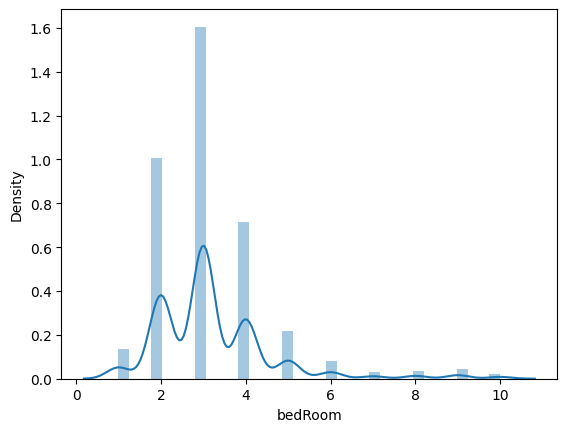

In [371]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

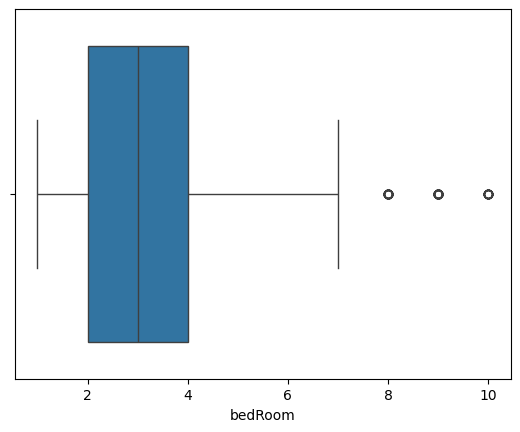

In [372]:
sns.boxplot(x=df['bedRoom'])

In [373]:
df['bedRoom'].describe()

count   3661.00
mean       3.21
std        1.40
min        1.00
25%        2.00
50%        3.00
75%        4.00
max       10.00
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

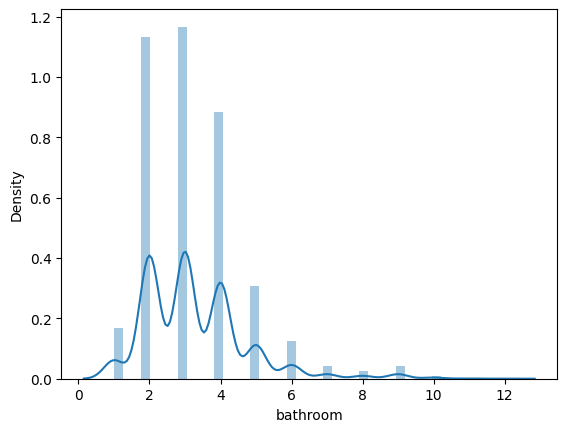

In [374]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

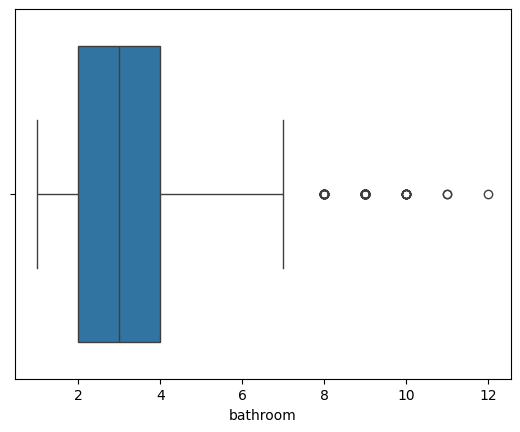

In [375]:
sns.boxplot(x=df['bathroom'])

In [376]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1200,house,adani brahma samsara,sector 60,18.02,28200.00,6390.00,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.00,North-East,Relatively New,NaN,6390.00,NaN,0,1,0,0,0,0,146
2603,house,independent,sector 24,11.00,28902.00,3806.00,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.00,East,Old Property,NaN,5000.00,NaN,1,1,0,1,1,0,39
3670,house,independent,sector 39,7.00,10000.00,7000.00,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.00,South-East,Relatively New,NaN,7000.00,NaN,0,0,0,1,0,0,38


### super built up area

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

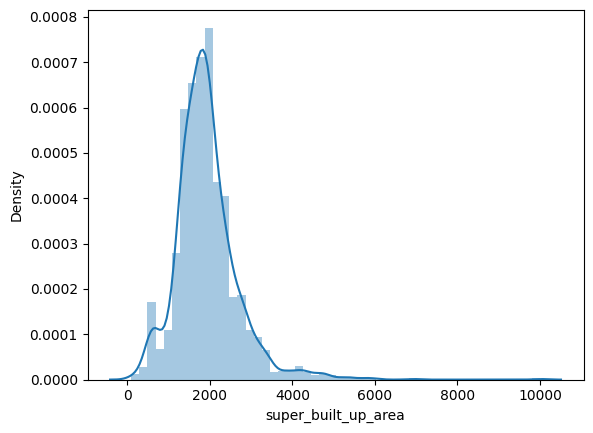

In [377]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

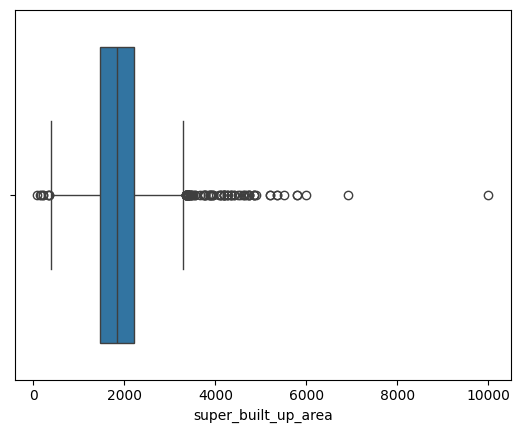

In [378]:
sns.boxplot(x=df['super_built_up_area'])

In [379]:
df['super_built_up_area'].describe()

count    1884.00
mean     1923.33
std       765.42
min        89.00
25%      1474.25
50%      1828.00
75%      2215.00
max     10000.00
Name: super_built_up_area, dtype: float64

In [380]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
60,flat,bestech park view grand spa,sector 81,4.70,6786.00,6926.00,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.00,North,Relatively New,6926.00,NaN,NaN,0,1,0,0,0,0,140
1724,flat,krrish provence estate,sector 2,7.50,7500.00,10000.00,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.00,North-East,Relatively New,10000.00,NaN,NaN,0,1,0,1,1,1,49


### built up area

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

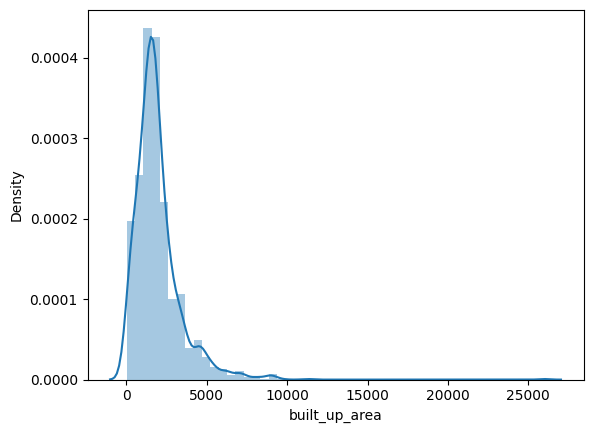

In [381]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

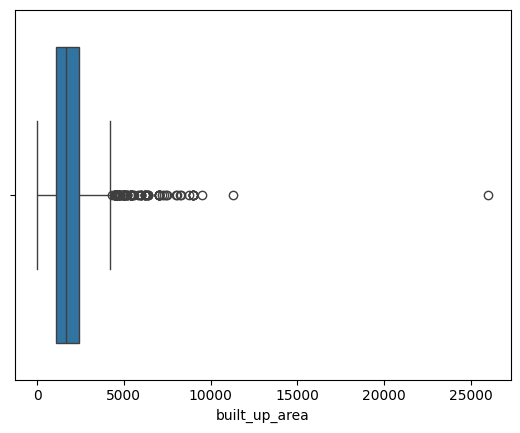

In [382]:
sns.boxplot(x=df['built_up_area'])

In [383]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2039,house,independent,sector 5,1.45,557.00,2415.00,Plot area 26000(2415.48 sq.m.),4,4,2,2.00,East,Moderately Old,NaN,26000.00,NaN,0,1,0,1,0,1,62
2310,house,independent,sector 43,27.50,24366.00,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.00,North-East,Relatively New,NaN,11286.00,NaN,1,1,0,1,1,0,42


In [384]:
df = df.drop(index=2039).reset_index(drop=True)

In [385]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2260,house,independent,sector 43,27.50,24366.00,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.00,North-East,Relatively New,NaN,11286.00,NaN,1,1,0,1,1,0,42


### carpet area

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

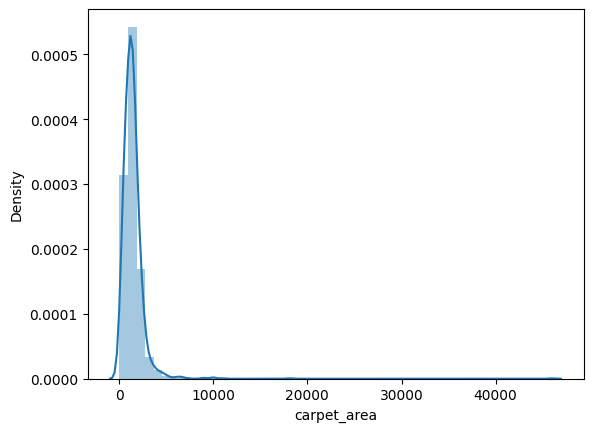

In [386]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

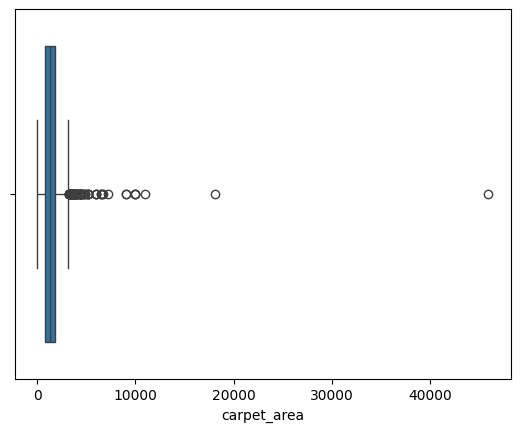

In [387]:
sns.boxplot(x=df['carpet_area'])

In [388]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1220,flat,m3m golfestate,sector 65,13.20,12000.00,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.00,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,1,60
1909,flat,ramsons kshitij,sector 95,0.24,53.00,4270.00,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.00,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,1,33
3157,flat,godrej air,sector 85,2.50,1379.00,1812.00,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.00,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,0,44


In [389]:
df.loc[3157,'carpet_area'] = 1812

In [390]:
df = df.drop(index=1909).reset_index(drop=True)

In [391]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1220,flat,m3m golfestate,sector 65,13.20,12000.00,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.00,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,1,60


### luxury_score

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

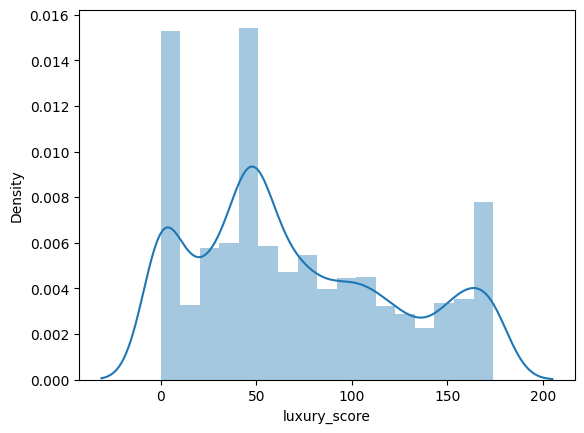

In [392]:
sns.distplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

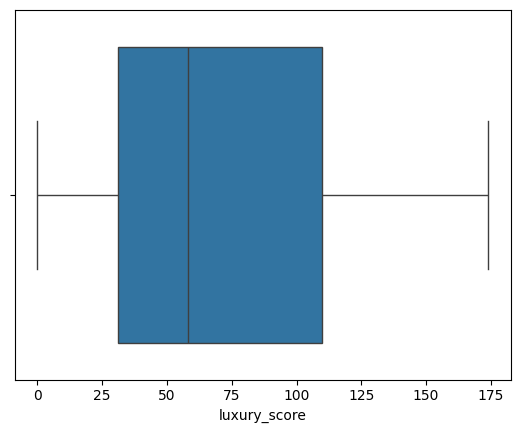

In [393]:
sns.boxplot(x=df['luxury_score'])

In [394]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 11,4.00,19753.00,2025.00,Built Up area: 225 (188.13 sq.m.)Carpet area: ...,5,4,1,2.00,North-East,Undefined,NaN,225.00,180.00,0,0,0,0,0,1,0
1,flat,indiabulls enigma,sector 110,3.30,9850.00,3350.00,Super Built up area 3350(311.23 sq.m.),4,5,3,7.00,East,Relatively New,3350.00,NaN,NaN,0,1,0,0,0,1,101
2,flat,puri emerald bay,sector 104,2.30,9387.00,2450.00,Super Built up area 2450(227.61 sq.m.),3,4,3+,10.00,North-East,Moderately Old,2450.00,NaN,NaN,0,1,0,0,0,1,101
3,house,nirvana cedar crest,sector 50,3.99,8866.00,4500.00,Plot area 4500(418.06 sq.m.),4,5,3+,4.00,North-East,New Property,NaN,4500.00,NaN,0,1,0,1,0,0,112
4,flat,bptp terra,sector 37,1.45,8006.00,1811.00,Super Built up area 1811(168.25 sq.m.)Built Up...,3,3,3,8.00,South-East,Relatively New,1811.00,1711.00,1611.00,0,0,0,0,0,1,149


In [395]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [396]:
df.shape

(3659, 23)

C:\Users\kushs\AppData\Local\Temp\ipykernel_48820\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

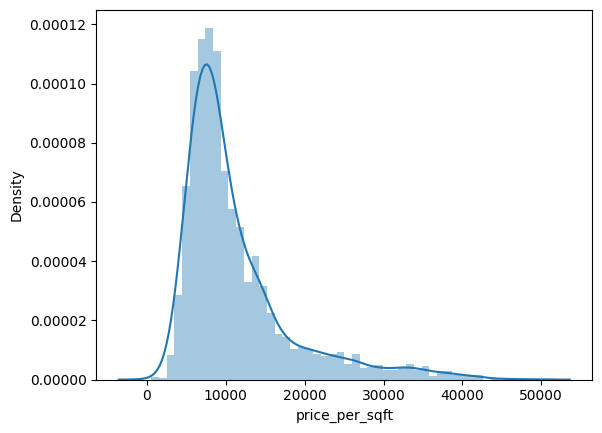

In [397]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

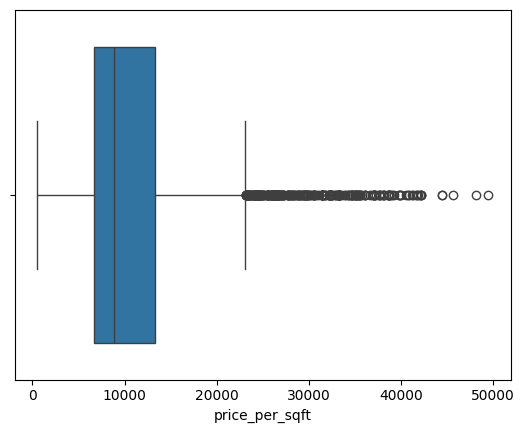

In [398]:
sns.boxplot(x=df['price_per_sqft'])

In [399]:
df[df['price_per_sqft'] > 42000].sort_values('price_per_sqft')

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1630,house,dlf city plots,sector 26,19.00,42054.00,4518.00,Plot area 502(419.74 sq.m.),6,6,3,2.00,East,Relatively New,NaN,4518.00,NaN,1,1,0,0,0,0,121
1552,house,independent,sector 28,12.00,42194.00,2844.00,Plot area 316(264.22 sq.m.),4,5,3+,4.00,East,Relatively New,NaN,2844.00,NaN,0,1,1,1,0,0,60
225,house,independent,sector 43,9.50,42222.00,2250.00,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.00,North-East,Relatively New,NaN,300.00,250.00,0,1,0,1,0,0,88
271,house,independent,sector 26,19.00,42222.00,4500.00,Plot area 500(418.06 sq.m.),6,8,3+,3.00,East,Moderately Old,NaN,4500.00,NaN,1,1,1,1,0,0,103
704,house,independent,sector 26,20.00,44444.00,4500.00,Plot area 500(418.06 sq.m.),5,7,3+,3.00,West,Relatively New,NaN,4500.00,NaN,0,1,0,1,0,2,97
1511,house,independent,sector 55,5.00,44444.00,1125.00,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.00,East,New Property,NaN,115.00,100.00,0,0,0,0,1,0,44
1266,house,independent,sector 25,13.00,45710.00,2844.00,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.00,NaN,1,1,1,1,0,2,0
2642,house,sushant lok 1 builder floors,sector 43,13.00,48148.00,2700.00,Plot area 300(250.84 sq.m.),3,3,3+,4.00,North,New Property,NaN,2700.00,NaN,0,0,0,1,0,0,7
2656,house,independent,sector 105,9.90,49500.00,2000.00,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.00,North,Undefined,NaN,2000.00,1800.00,0,0,0,0,0,1,0


In [400]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(250.0)

In [401]:
df[(df['area']/df['bedRoom'])<250]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
28,flat,mvn athens,sohna,0.26,5394.00,482.00,Carpet area: 481.73 (44.75 sq.m.),2,2,1,5.00,NaN,Relatively New,NaN,NaN,481.68,0,0,0,0,0,1,95
36,house,independent,sector 46,4.35,23693.00,1836.00,Plot area 204(170.57 sq.m.),8,8,2,3.00,North-East,Relatively New,NaN,1836.00,NaN,1,0,0,1,0,0,19
55,house,housing board colony,sector 28,2.10,23333.00,900.00,Plot area 100(83.61 sq.m.),8,8,3+,4.00,South-East,Moderately Old,NaN,900.00,NaN,0,0,0,0,1,0,38
72,house,independent,sector 7,0.27,12000.00,225.00,Plot area 225(20.9 sq.m.),2,2,1,2.00,North-East,Moderately Old,NaN,225.00,NaN,0,0,0,0,0,1,12
75,flat,pivotal devaan,sector 84,0.34,7039.00,483.00,Carpet area: 483 (44.87 sq.m.),2,2,1,1.00,East,Relatively New,NaN,NaN,483.00,0,0,1,0,0,0,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3540,house,independent,sector 11,2.10,17284.00,1215.00,Plot area 135(112.88 sq.m.),6,6,3+,3.00,NaN,Relatively New,NaN,1215.00,NaN,0,0,0,0,0,1,14
3551,house,independent,sector 110,2.00,14914.00,1341.00,Plot area 1341(124.58 sq.m.),6,4,3,3.00,East,Relatively New,NaN,1341.00,NaN,1,0,0,1,0,0,36
3640,house,independent,sector 7,1.20,11194.00,1072.00,Built Up area: 1072 (99.59 sq.m.),5,4,2,3.00,NaN,Undefined,NaN,1072.00,NaN,0,0,0,0,0,1,0
3651,house,huda floor,sector 38,4.00,22222.00,1800.00,Plot area 1800(167.23 sq.m.)Built Up area: 480...,9,9,3+,2.00,East,Relatively New,NaN,4800.00,3800.00,0,0,1,1,0,0,152


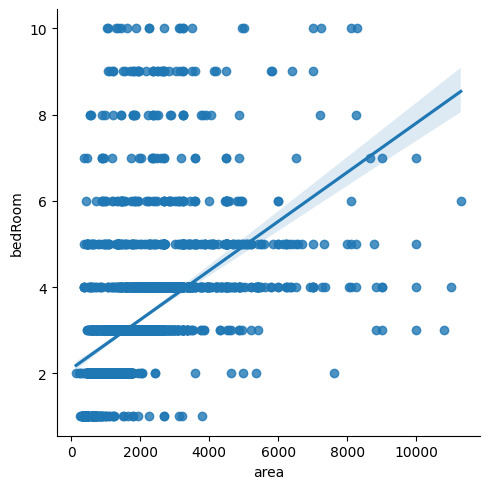

In [402]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [403]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [404]:
# df[(df['area']/df['bedRoom'])<250].to_excel('outlier_ratio.xlsx')

In [405]:
df=df[df['area_room_ratio']>100]

In [406]:
outliers_df=df[(df['area_room_ratio']<250) & (df['bedRoom']>3)]

In [407]:
outliers_df=outliers_df[outliers_df['floorNum']!=0]

In [408]:
outliers_df['bedRoom']=round(outliers_df['bedRoom']/outliers_df['floorNum'])

In [409]:
df.update(outliers_df)

In [410]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [412]:
df[(df['area_room_ratio']<250)& (df['bedRoom']>4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
300,house,independent,sector 5,0.85,9444.00,900.00,Carpet area: 900 (83.61 sq.m.),5,3,3,1.00,NaN,Undefined,NaN,NaN,900.00,0,0,0,0,0,1,0,180.00
595,house,independent,sector 11,3.50,15556.00,2250.00,Built Up area: 2250 (209.03 sq.m.),10,1,0,1.00,NaN,New Property,NaN,2250.00,NaN,0,0,0,0,0,1,0,225.00
827,house,independent,sector 1,1.10,6173.00,1782.00,Plot area 1782(165.55 sq.m.),8,8,0,1.00,NaN,New Property,NaN,1782.00,NaN,0,0,0,0,0,1,0,222.75
1269,house,independent,sector 12,2.50,13889.00,1800.00,Plot area 1800(167.23 sq.m.),9,5,2,1.00,South-East,Old Property,NaN,1800.00,NaN,0,0,0,1,0,1,8,200.00
1747,house,independent,sector 1,0.80,6667.00,1200.00,Plot area 1200(111.48 sq.m.),8,8,2,1.00,NaN,Relatively New,NaN,1200.00,NaN,0,0,0,0,0,1,0,150.00
1875,house,independent,sector 7,1.16,11717.00,990.00,Carpet area: 110 (91.97 sq.m.),5,4,2,1.00,North-East,Undefined,NaN,NaN,110.00,0,0,0,0,0,1,0,198.00
2232,house,shivpuri,sector 7,2.80,12444.00,2250.00,Plot area 2250(209.03 sq.m.),10,7,3,1.00,NaN,Old Property,NaN,2250.00,NaN,1,1,0,1,1,0,0,225.00
2285,house,independent,sector 23,0.98,9074.00,1080.00,Carpet area: 120 (100.34 sq.m.),9,4,3,1.00,South,Undefined,NaN,NaN,120.00,0,0,0,0,0,1,0,120.00
2293,house,independent,sector 5,1.10,10000.00,1100.00,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.00,East,Undefined,NaN,1100.00,900.00,0,0,0,0,0,1,0,220.00
2582,house,independent,sector 105,1.10,12222.00,900.00,Carpet area: 900 (83.61 sq.m.),6,4,1,1.00,South-West,Undefined,NaN,NaN,900.00,0,0,0,0,0,1,0,150.00


In [414]:
df[(df['area_room_ratio']<250)& (df['bedRoom']>4)].shape

(13, 24)

In [415]:
df=df[~((df['area_room_ratio']<250)& (df['bedRoom']>4))]

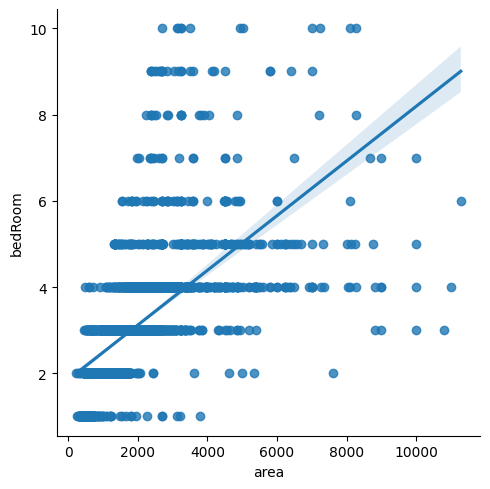

In [416]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [417]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)